# Modular Arithmetic with `hierarqcal`

In [ ]:
# imports

from hierarqcal import (
    Qcycle,
    Qmotif,
    Qinit,
    Qmask,
    Qunmask,
    Qpermute,
    Qpivot,
    plot_circuit,
    plot_motif,
    get_tensor_as_f,
    Qunitary,
    Qhierarchy,
)
import numpy as np
import sympy as sp
import itertools as it

### Motivation

In the world of quantum information, our operators adhere to the principles of unitarity, denoted by
$ U = U^\dagger = U^{-1} $. However, it's crucial to recognize that not all operators possess Hermitian properties. Consider, for instance, a rotation gate such as
$ R_z(\theta) $, which fails to be Hermitian ($ R_z(\theta)R_z(\theta)\ket{\psi}=R_z(2\theta)\ket{\psi} $). Nonetheless, the unitarity requirement itself imposes significant constraints, particularly in ensuring reversible computation. This is due to the fact that
$ U^\dagger = U^{-1} $, where the existence of the inverse
$ U^\dagger $ is encoded within the matrix structure.

The unitarity constraint serves multiple purposes beyond enabling reversibility. It guarantees that any states we create remain normalized, as evident from
$ \langle 0 | U^\dagger U | 0 \rangle = 1 $, ensuring our probabilities sum to one. Additionally, the unitary evolution of a state is considered a fundamental postulate in quantum mechanics. However, it's noteworthy that while the circuit's evolution is unitary, its "log" is Hermitian. By solving the Schrödinger equation, we express
$ U\ket{\psi}=e^{-\frac{i}{\hbar}\hat{H}t}\ket{\psi} $, where
$ \hat{H} $ represents the Hamiltonian, or the Energy operator. Ensuring the Hermitian nature of
$ \hat{H} $ is crucial, as it guarantees real-valued energies, a cornerstone requirement in quantum mechanics.

Now, transitioning to the world of classical and quantum algorithms, the seamless translation of classical methods to their quantum counterparts faces hurdles. While classical algorithms effortlessly handle modular arithmetic, the unitary nature of quantum operators demands a more thoughtful approach. Consider a quantum state
$ \ket{\psi} $ subjected to a unitary operator
$ U $: applying
$ U $ yields another state
$ \ket{\phi} = U\ket{\psi} $. Remarkably, applying
$ U $ again retrieves the initial state
$ \ket{\psi} $, exemplifying the inherent reversibility of unitary operations. Consequently, implementing modular arithmetic in the quantum realm necessitates careful consideration and innovative approaches.

But fret not, for `hierarqcal` stands ready to guide us through the creation of a quantum arithmetic machine from scratch!


### Intuition: Classical Adders

To start, let's understand how classical adder circuits work.

### Half Adder

Suppose we have two bits, $A$ and $B$. We can add them through the following circuit, which copies the input bits to make two pairs, and applies an $\text{XOR}$ gate to one pair and a $\text{AND}$ gate to the other pair.

![alt text](Half_Adder.png "Schematic of a Half Adder (Wikipedia)")

This half adder circuit returns two bits, $S$ ('sum') and $C$ ('carry'). To see that it works, we can look at the truth table below (try it out yourself to check!):

|  A   |  B   |  C   |  S   |
| ---- | ---- | ---- | ---- |
|  0   |  0   |  0   |  0   |
|  0   |  1   |  0   |  1   |
|  1   |  0   |  0   |  1   |
|  1   |  1   |  1   |  0   |

Great! However, there's just one problem... the half adder is great for adding single bits, but in practice we will want to add large numbers that are comprised of many bits. But never fear - we can do this like we learned in first grade - by adding the least significant bits first and then sequentially adding the next least significant bits, along with any carried values from the previous operations.

However, the half adder can only add two bits, not the required three (two regular bits and one carry bit). This motivates the development of the *full adder*.


### Full Adder

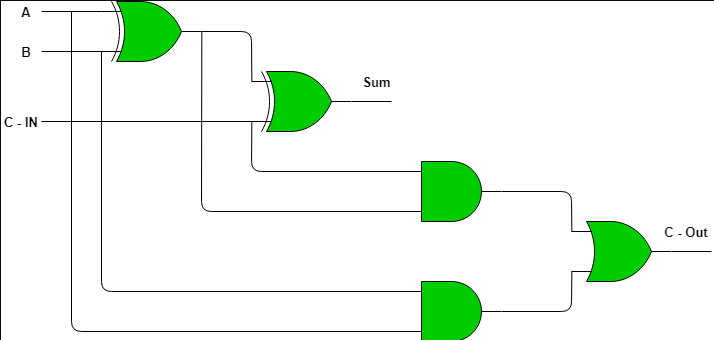


 Image from [Geeks for Geeks](https://www.geeksforgeeks.org/full-adder-in-digital-logic/)

Instead of taking two bits as input, the full adder takes *three* - $A$, $B$, and $C$ - where $C$ represents a carry bit from the previous operation. The full adder works similarly to the half adder, but with two $\text{XOR}$ gates, two $\text{AND}$ gates, and one $\text{OR}$ gate. The number of output bits remains the same, so our truth table now looks like the following:

|  A   |  B   |  $C_{\text{in}}$   |  $C_{\text{out}}$   |  S   |
| ---- | ---- | ---- | ---- | ---- |
|  0   |  0   |  0   |  0   |  0   |
|  0   |  0   |  1   |  0   |  1   |
|  0   |  1   |  0   |  0   |  1   |
|  0   |  1   |  1   |  1   |  0   |
|  1   |  0   |  0   |  0   |  1   |
|  1   |  0   |  1   |  1   |  0   |
|  1   |  1   |  0   |  1   |  0   |
|  1   |  1   |  1   |  1   |  1   |

### Quantum Adders: Building Blocks
*Quick note: if any of this is familiar/boring to you, feel free to skip ahead! Conversely, if you're new to quantum circuits and/or `hierarqcal`, check out our core tutorial in `examples/core_tutorial.ipynb`!*

Similarly to the classical case, our quantum adder will rely on two crucial operations: a *sum* operation and a *carry* operation.

1. Gates
   - Turns out we only need a few gates to make this happen: $NOT, CNOT, SWAP, \text{Toffoli}$, and $\text{Hadamard}$. With the exception of $\text{Hadamard}$, all of these are gates in classical computing as well.
2. Subcircuits for a (vanilla) qArithmetic algorithm
   - First, we'll build a *carry* circuit and a *sum* circuit.
   - Then, we'll construct a quantum adder circuit with these.
3. Building a *modular* qArithmetic algorithm

In [ ]:
def get_bitlist(a, n):
    """
    Returns a list of bits of length n representing the integer a.
    """
    a_bits = [int(b) for b in bin(a)[2:]]
    a_bits = [0] * (n - len(a_bits)) + a_bits
    return a_bits

def get_results(result_tensor, bit_layout):
    result = "".join([str(bit[0]) for bit in np.where(result_tensor == 1)])
    # register_r = [bit for bit, label in zip(result, bit_layout) if label == "r"]
    # register_x = [bit for bit, label in zip(result, bit_layout) if label == "x"]
    register_a = [bit for bit, label in zip(result, bit_layout) if label == "a"]
    register_b = [bit for bit, label in zip(result, bit_layout) if label == "b"]
    register_bc = [bit for bit, label in zip(result, bit_layout) if label == "bc"]
    register_c = [bit for bit, label in zip(result, bit_layout) if label == "c"]
    register_n = [bit for bit, label in zip(result, bit_layout) if label == "N"]
    register_n1 = [bit for bit, label in zip(result, bit_layout) if label == "t1"]
    # print(f"r: {register_r}")
    # print(f"x: {register_x}")
    print(f"a: {register_a}")
    print(f"b: {register_b} + {register_bc}")
    print(f"c: {register_c}")
    print(f"n: {register_n}")
    print(f"t: {register_n1}")
    return result, register_a, register_b, register_c, register_n, register_n1

def get_tensors(N, n, a=None, b=None):
    ket0 = np.array([1, 0])
    ket1 = np.array([0, 1])
    # Get bits
    a_bits = get_bitlist(a, n) if a is not None else [0] * n
    b_bits = get_bitlist(b, n) if b is not None else [0] * n
    modn = get_bitlist(N, n)
    # r_bits = get_bitlist(r, n)
    # x_bits = get_bitlist(x, n)
    # add r and x
    # r_tensors = [ket0 if elem == 0 else ket1 for elem in r_bits[::-1]]
    # x_tensors = [ket0 if elem == 0 else ket1 for elem in x_bits[::-1]]
    # init a,b,c to 0
    abc_tensors = [
        ket0 if elem == 0 else ket1
        for triplet in zip([0] * n, a_bits[::-1], b_bits[::-1])
        for elem in triplet
    ]
    bc_tensor = [ket0]
    N_tensors = [ket0 if elem == 0 else ket1 for elem in modn[::-1]]
    t0_tensor = [ket0]
    tensors =  abc_tensors + bc_tensor + N_tensors + t0_tensor
    return tensors

N = 4 # the modulus
a = 4 # the first number we want to add
b = 3 # the second number we want to add

n = 4 # number of bits we use to store t
print(f"a - {a}\nb - {b}\nN - {N}\n")
bit_layout = ["c", "a", "b"] * n + ["bc"] + ["N"] * n + ["t1"]
nq = len(bit_layout)
tensors = get_tensors(N, n, a=a, b=b)

mask_part = lambda part, inv=False: Qmask(
    "".join(
        [str((1 + inv) % 2) if b in part else str((0 + inv) % 2) for b in bit_layout]
    )
)

a - 4
b - 3
N - 4



### 1. Gates
First, let's build some quantum gates! *For a refresher on the objects used in hierarqcal, see `examples/core_tutorial.ipynb` or check out the docs.*

In [ ]:
# === Building matrices === #
toffoli_m = np.identity(8)
toffoli_m[6, 6] = 0
toffoli_m[6, 7] = 1
toffoli_m[7, 6] = 1
toffoli_m[7, 7] = 0
cnot_m = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
h_m = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]])
swap_m = np.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]])
x_m = np.array([[0, 1], [1, 0]])

# === Making our matrices into gates in hierarqcal! === #
toffoli = Qunitary(get_tensor_as_f(toffoli_m), 0, 3)
cnot = Qunitary(get_tensor_as_f(cnot_m), 0, 2)
hadamard = Qunitary(get_tensor_as_f(h_m), 0, 1)
swap = Qunitary(get_tensor_as_f(swap_m), 0, 2)
x = Qunitary(get_tensor_as_f(x_m), 0, 1)

### 2. Subcircuits

Now that we have our gates, let's look at the carry and sum circuits a little more closely. We're going to follow a method inspired by the classical method of summing each digit at a time.

In [ ]:
# === Carry and Sum === #

carry_motif = (
    Qinit(4)
    + Qmotif(E=[(1, 2, 3)], mapping=toffoli)
    + Qmotif(E=[(1, 2)], mapping=cnot)
    + Qmotif(E=[(0, 2, 3)], mapping=toffoli)
)

# Turn carry into a function to be able to reverse it easily
carry = lambda r: carry_motif if r == 1 else carry_motif.reverse()

sum = lambda r=1: Qinit(3) + Qpivot(
    "*1", merge_within="01", mapping=cnot, edge_order=[-1 * r]
)

# Verifying our results!
# plot_circuit(carry(1))
# plot_circuit(carry(-1))
# plot_circuit(sum(1))
# plot_circuit(sum(-1))
hierq = (
    Qinit(nq, tensors=tensors)
    + Qmotif(E=[(0, 1, 2,3)], mapping=carry(1))
)
result_tensor = hierq()

get_results(result_tensor, bit_layout)
del result_tensor

a: ['0', '0', '1', '0']
b: ['1', '1', '0', '0'] + ['0']
c: ['0', '0', '0', '0']
n: ['0', '0', '1', '0']
t: ['0']


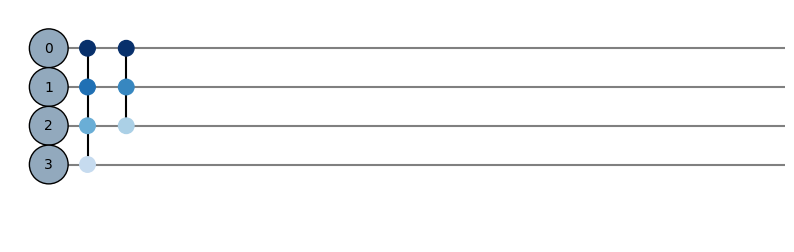

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

In [ ]:
# === Making motifs from carry and sum === #
carry_sum_motif = (
    lambda r=1: Qinit(4)
    + Qpivot("1*", merge_within="1111", mapping=carry(-r))
    + Qpivot("1*", merge_within="111", mapping=sum(r))
)
carry_sum = lambda r=1: carry_sum_motif(1) if r == 1 else carry_sum_motif(-1).reverse()


cnot_sum_motif = (
    lambda r=1: Qinit(3)
    + Qpivot("*1", merge_within="11", mapping=cnot)
    + Qpivot("*1", merge_within="111", mapping=sum(r))
)
cnot_sum = lambda r=1: cnot_sum_motif(1) if r == 1 else cnot_sum_motif(-1).reverse()

plot_circuit(carry_sum(1))

In [ ]:
# === A (vanilla) qArithmetic machine === #

carry_layer = lambda r=1: Qcycle(
    1,
    3,
    0,
    mapping=carry(r),
    boundary="open",
    edge_order=[r],
)

cnot_sum_pivot = lambda r: Qpivot("*10", merge_within="111", mapping=cnot_sum(r))
carry_sum_layer = lambda r: (
    Qmask("*111")
    + Qcycle(
        1,
        3,
        0,
        boundary="open",
        mapping=carry_sum(r),
        edge_order=[-r],
    )
    + Qunmask("previous")
)

addition = (
    mask_part(["N", "t1"], inv=False)
    + carry_layer(1)
    + cnot_sum_pivot(1)
    + carry_sum_layer(1)
    + Qunmask("previous")
)
subtraction = (
    mask_part([ "N", "t1"], inv=False)
    + carry_sum_layer(-1)
    + cnot_sum_pivot(-1)
    + carry_layer(-1)
    + Qunmask("previous")
)

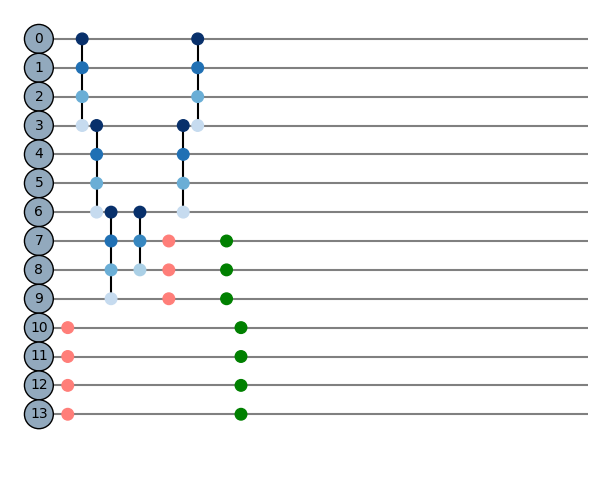

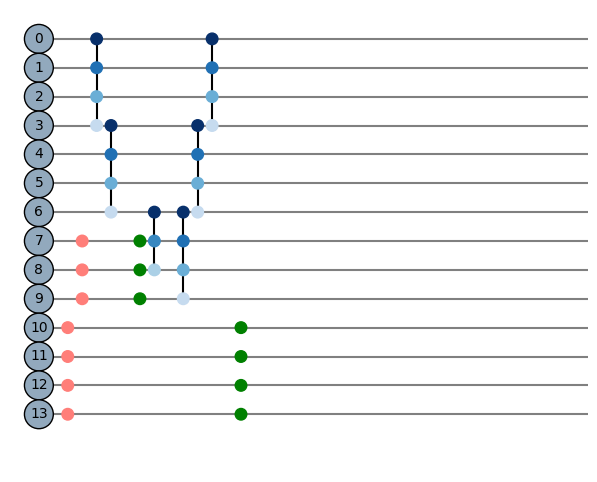

a: ['0', '0', '1']
b: ['1', '1', '1'] + ['0']
c: ['0', '0', '0']
n: ['0', '0', '1']
t: ['0']


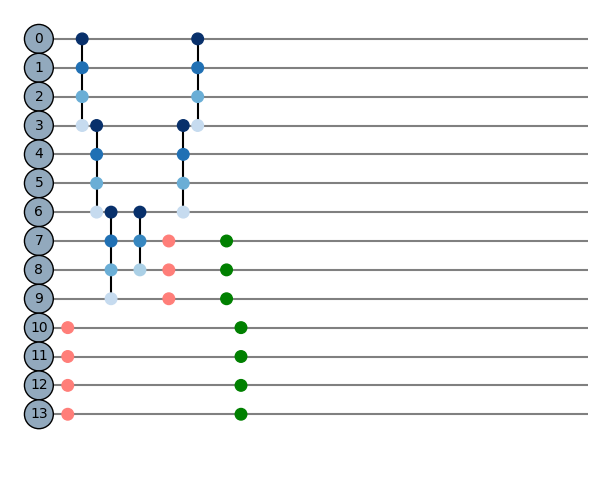

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

In [ ]:
## Testing
plot_circuit(Qinit(nq)+addition)
plot_circuit(Qinit(nq)+subtraction)
hierq = (
    Qinit(nq, tensors=tensors)
    + addition
)
result_tensor = hierq()
get_results(result_tensor, bit_layout)
del result_tensor
plot_circuit(hierq)

### 3. Building a quantum modular arithmetic algorithm

Since we have a basic adder, now we can build one that does $\text{mod}~N$ addition.

First, we'll make good use of the following fact: since $N>a,b$, we can easily see that $a+b < 2N~\forall a,b$.

Therefore, all we need to do is add $a$ and $b$ and subtract $N$. If $a+b < N$ we should not perform the subtraction, luckily this information is encoded in the $b-carry$ ($b_c$) register ($b_c = 1$ if $a+b>N$, so we'll use that to decide whether we subtract N or not).

We achieve this by swapping register $a$ and $N$. Then we use $t_1$ (temporary bit) to store whether $a+b>n~$(i.e. $b_c=1$). So we flip $b_c$, perform $CNOT$ onto $t_1$ and flip back. Now, we want to set all the ones of $N$ to 0 if $t_1 = 1$. This is done by masking all but register $a$ and $t_1$, then masking all the zeros of $N and finally pivot cnots controls onto $t_1$ where the targets cycle through the available bits of register $a$.

In [ ]:
# Build motif to swap a with N
swap_an = (
    mask_part(["a", "N"], inv=True)
    + Qcycle(n, 2, 0, mapping=swap, boundary="periodic")
    + Qunmask("previous")
)
# Build motif to flip temporary bit based on b carry
ctrl_not_bc_tmp_x = (
    mask_part(["bc", "t1"], inv=True)
    + Qpivot("10", mapping=x)
    + Qpivot("01", merge_within="01", mapping=cnot)
    + Qpivot("10", mapping=x)
    + Qunmask("previous")
)
# Build a motif that control flips the temporary bit without flipping bc
ctrl_not_bc_tmp = (
    mask_part(["bc", "t1"], inv=True)
    + Qpivot("01", merge_within="01", mapping=cnot)
    + Qunmask("previous")
)

# Build motif that sets "a" register to 0 if there wasn't an overflow
zeros_of_N = "".join([str((bit + 1) % 2) for bit in get_bitlist(N, n)])
reset_if_overflow = (
    mask_part(["a", "t1"], inv=True)
    + Qmask(zeros_of_N[::-1])
    + Qpivot(global_pattern="*1", merge_within="10", mapping=cnot)
    + Qunmask("previous")
    + Qunmask("previous")
)

In [ ]:
# here are our modular quantum arithmetic machines!
addition_mod_n = (
    addition
    + swap_an
    + subtraction
    + ctrl_not_bc_tmp_x
    + reset_if_overflow
    + addition
    + reset_if_overflow
    + swap_an
    + subtraction
    + ctrl_not_bc_tmp
    + addition
)

subtraction_mod_n = (
    subtraction
    + ctrl_not_bc_tmp
    + addition
    + swap_an
    + reset_if_overflow
    + subtraction
    + reset_if_overflow
    + ctrl_not_bc_tmp_x
    + addition
    + swap_an
    + subtraction
)

In [ ]:
# === verify
hierq = (
    Qinit(nq, tensors=tensors)
    + addition_mod_n
    #+ subtraction_mod_n
)
result_tensor = hierq()
get_results(result_tensor, bit_layout)
del result_tensor
plot_circuit(hierq, plot_width=100)

## Introduction

Modular arithmetic is a fundamental concept in mathematics with diverse applications in computer science and cryptography. It involves arithmetic operations performed on integers within a fixed range, known as the modulus. In this tutorial, we'll explore how modular arithmetic can be implemented using quantum circuits with the HierarQcal package.

## Quantum Circuits for Modular Arithmetic

To perform modular addition and subtraction using quantum circuits, we need to understand the underlying principles of quantum gates and operations. Quantum circuits for modular arithmetic typically involve operations such as controlled gates, conditional branching, and bitwise manipulation. We'll delve into the specifics of these circuits and how they facilitate modular arithmetic computations.

## Implementation in HierarQcal

HierarQcal is a Python package that provides a framework for designing and simulating quantum circuits. We'll learn how to leverage HierarQcal's components such as Qunitary, Qcycle, Qmask, and Qpivot to implement modular addition and subtraction algorithms. Through code examples and explanations, we'll demonstrate how to construct quantum circuits for modular arithmetic operations.

## Demonstration

In this section, we'll walk through practical examples of modular addition and subtraction using HierarQcal. Starting with simple inputs, we'll step through the execution of quantum circuits, explaining each stage of the computation. By examining the results, we'll gain insights into how quantum circuits perform modular arithmetic and handle various scenarios.

## Visualization

Visualizing quantum circuits is crucial for understanding their behavior and structure. With HierarQcal's visualization tools, we'll generate graphical representations of the quantum circuits involved in modular arithmetic. These visualizations will provide intuitive insights into the quantum operations performed during modular arithmetic computations.

By the end of this tutorial, you'll have a solid understanding of how modular arithmetic can be implemented using quantum circuits with HierarQcal. You'll also gain proficiency in visualizing and interpreting quantum circuits, enabling you to explore more advanced quantum computing concepts.

Modular arithmetic, also known as clock arithmetic, is a mathematical operation performed on integers that results in remainders. It involves calculating the remainder when dividing one integer by another, called the modulus. In modular arithmetic, two integers are considered congruent if they have the same remainder when divided by the modulus. This concept is denoted as $a \equiv b \pmod{m}$, where $a$ and $b$ are integers, and $m$ is the modulus.



In modular addition, we add two integers and take the remainder when divided by the modulus. For example, $(a + b) \mod m$. If the sum exceeds the modulus, we wrap around to the beginning of the clock face. This operation is often represented as $a +_m b$.



Similarly, modular subtraction involves subtracting one integer from another and taking the remainder when divided by the modulus. For example, $(a - b) \mod m$. If the result is negative, we add the modulus to obtain a positive remainder. This operation is represented as $a -_m b$.



In modular multiplication, we multiply two integers and take the remainder when divided by the modulus. For example, $(a \times b) \mod m$. This operation is often represented as $a \times_m b$.



Modular arithmetic has various applications in computer science, cryptography, and number theory. It is used in algorithms for hashing, error detection and correction, and generating pseudorandom numbers. In cryptography, modular arithmetic forms the basis of public-key cryptography algorithms such as RSA.


To perform modular addition and subtraction using quantum circuits, we need to understand the underlying principles of quantum gates and operations. Quantum circuits for modular arithmetic typically involve operations such as controlled gates, conditional branching, and bitwise manipulation. We'll delve into the specifics of these circuits and how they facilitate modular arithmetic computations.



Controlled gates are fundamental building blocks in quantum circuits for modular arithmetic. These gates perform operations on a target qubit only when a control qubit is in a specific state. For example, in modular addition, we might use a controlled-NOT gate (CNOT), where the control qubit represents a condition such as whether the sum exceeds the modulus.



Conditional branching allows quantum circuits to execute different sequences of operations based on the outcome of previous computations. In modular arithmetic, conditional branching is used to handle overflow conditions and adjust the result accordingly. For example, if the sum of two numbers exceeds the modulus, the circuit might subtract the modulus to wrap around and obtain the correct result.



Bitwise manipulation is essential for performing modular arithmetic operations at the quantum level. Quantum circuits manipulate individual bits of quantum states to perform addition, subtraction, and other bitwise operations. This involves applying quantum gates such as X (bit-flip), CNOT (controlled-NOT), and Toffoli gates to manipulate qubits representing binary numbers.



Quantum circuits for modular arithmetic have various applications in quantum computing and cryptography. They can be used to implement quantum algorithms for factoring large numbers, solving discrete logarithm problems, and implementing secure cryptographic protocols such as quantum key distribution (QKD) and homomorphic encryption.



Below is a simplified example of a quantum circuit for modular addition:



\[
\begin{array}{cccc}
\text{Input} & \text{---} & \text{Controlled Operations} & \text{Output} \\
\hline
a, b, N & \text{---} & \text{Controlled Addition} & (a + b) \mod N \\
\end{array}
\]


In this circuit, $a$, $b$, and $N$ are input qubits representing the operands and modulus, respectively. The controlled addition operation computes the sum $(a + b) \mod N$ and outputs the result.


# Quantum Circuits for Modular Arithmetic using HierarQcal

In this tutorial, we will explore how to implement modular addition and subtraction using quantum circuits with the HierarQcal framework. We will break down the process into clear steps, explaining each concept and component before demonstrating how to implement it. By the end of this tutorial, you will have a solid understanding of how to construct quantum circuits for modular arithmetic operations.

## Prerequisites

Before we begin, ensure you have HierarQcal installed. You can install it using pip:

```bash
pip install hierarqcal
```

Introduction to HierarQcal
HierarQcal is a Python package that provides a framework for designing and simulating quantum circuits. It offers components such as Qunitary, Qcycle, Qmask, and Qpivot to help build complex quantum operations.

Modular Arithmetic
Modular arithmetic involves operations where numbers wrap around upon reaching a certain value, known as the modulus. In quantum computing, modular addition and subtraction are fundamental operations with applications in cryptography and number theory.

Section 1: Setting Up the Environment
First, we need to import the necessary modules from HierarQcal and set up our environment.

In [ ]:
# Import necessary modules from HierarQcal
from hierarqcal import Qunitary, Qcycle, Qmask, Qpivot

we define a class ModularAddition for performing modular addition on qubits. Modular addition is a mathematical operation where the sum is wrapped around a certain value (modulus). In quantum computing, it's used for specific quantum algorithms.


Import:

from hierarqcal import Qunitary: This line imports the Qunitary class, likely from a library named hierarchical (with a typo). It suggests the ModularAddition class inherits properties from Qunitary.
Class Definition:

class ModularAddition(Qunitary):: This defines a class named ModularAddition that inherits from the Qunitary class. This implies ModularAddition objects will have functionalities similar to Qunitary objects.
Initialization:

def __init__(self, modulus):: This defines the constructor for the ModularAddition class. It takes one argument, modulus, which represents the value used for wrapping the sum in the modular addition operation.
super().__init__(): This line calls the parent class (Qunitary) constructor to initialize any attributes it might have.
self.modulus = modulus: This assigns the provided modulus value to an attribute of the current object (self).

In [ ]:
from hierarqcal import Qunitary

class ModularAddition(Qunitary):
    def __init__(self, modulus):
        super().__init__()
        self.modulus = modulus

    def apply(self, qubits):
        # Define the modular addition operation here
        pass


we define a class ControlledModularAddition for performing a controlled modular addition operation on qubits. Controlled modular addition is a quantum operation where the modular addition is applied to a target qubit only when another qubit (the control qubit) is in a specific state (usually the state |1>).



Import:

from hierarqcal import Qcycle, Qmask: This line imports two classes, Qcycle and Qmask, likely from a library named hierarchical (with a typo).
Qcycle might be a context manager for executing a sequence of quantum operations.
Qmask is likely used to apply an operation to specific qubits based on their states.
Class Definition:

class ControlledModularAddition(Qunitary):: This defines a class named ControlledModularAddition that inherits from the Qunitary class. This suggests ControlledModularAddition objects will have functionalities similar to Qunitary objects.
Initialization:

def __init__(self, modulus):: This defines the constructor for the ControlledModularAddition class. It takes one argument, modulus, which represents the value used for wrapping the sum in the modular addition operation.
super().__init__(): This line calls the parent class (Qunitary) constructor to initialize any attributes it might have.
self.modulus = modulus: This assigns the provided modulus value to an attribute of the current object (self).
Controlled Modular Addition Operation (Incomplete):

def apply(self, qubits):: This defines a method named apply that takes a list of two qubits as input. The first qubit (control) likely controls the application of the modular addition, and the second qubit (target) is the one the modular addition is applied to.
with Qcycle():: This line uses the Qcycle context manager, possibly to group a sequence of quantum operations within the controlled modular addition.
Qmask(control, target): This line likely applies a masking operation using the Qmask class. The control and target qubits are specified as arguments. This might ensure the subsequent operations are only applied when the control qubit is in the desired state

In [ ]:
from hierarqcal import Qcycle, Qmask

class ControlledModularAddition(Qunitary):
    def __init__(self, modulus):
        super().__init__()
        self.modulus = modulus

    def apply(self, qubits):
        control, target = qubits
        with Qcycle():
            Qmask(control, target)
            # Define controlled addition logic here
            pass


we define a class BitwiseModularAddition for performing a potential bitwise modular addition operation on qubits. However, there's a key point to consider.

Possible Interpretation:

Bitwise vs. Modular Addition: The class name suggests "bitwise" modular addition, which might be a typo or a concept specific to the chosen quantum circuit framework. Standard modular addition operates on the overall value represented by the qubits, not individual bits.
Code Breakdown:



from hierarqcal import Qpivot: This line imports the Qpivot class, likely from a library named hierarchical (with a typo). The purpose of Qpivot is unclear from the provided snippet.
Class Definition:

class BitwiseModularAddition(Qunitary):: This defines a class named BitwiseModularAddition that inherits from the Qunitary class. This suggests BitwiseModularAddition objects will have functionalities similar to Qunitary objects.
Initialization:

def __init__(self, modulus):: This defines the constructor for the BitwiseModularAddition class. It takes one argument, modulus, which represents the value used for wrapping the sum in the modular addition operation. This aligns with standard modular addition.
super().__init__(): This line calls the parent class (Qunitary) constructor to initialize any attributes it might have.
self.modulus = modulus: This assigns the provided modulus value to an attribute of the current object (self).

In [ ]:
from hierarqcal import Qpivot

class BitwiseModularAddition(Qunitary):
    def __init__(self, modulus):
        super().__init__()
        self.modulus = modulus

    def apply(self, qubits):
        control, target = qubits
        with Qpivot():
            Qmask(control, target)
            # Define bitwise manipulation logic here
            pass


two functions, controlled_addition and controlled_subtraction, for implementing simplified controlled addition and subtraction circuits on qubits.



controlled_addition Function:

This function takes four arguments:
a: A list representing the first operand (potentially multiple qubits).
b: A list representing the second operand (potentially multiple qubits).
N: Likely the number of qubits involved in the operation (unclear from this snippet).
carry: A single qubit representing the carry bit from the previous addition (if applicable).
Qcycle([ ... ]): This line uses the Qcycle context manager (potentially from a custom library) to group a sequence of quantum operations.
Inside the loop:
Qunitary(a[0]).C(b[0]): This line applies a controlled operation (likely a CNOT gate) between the first qubit of a and the first qubit of b. The specific gate and control condition depend on the chosen quantum circuit framework. This step likely performs the addition of the least significant bits.
Qunitary(a[1]).C(b[1]).C(carry[0]): This line applies another controlled operation (potentially a Toffoli gate) between the second qubit of a, the second qubit of b, and the carry qubit. This step likely performs the addition of the next bit while considering the carry from the previous addition.

controlled_subtraction Function:

This function structure and arguments appear identical to controlled_addition. The key difference likely lies in the specific quantum gates used within the Qcycle loop.
The gates might involve inverting one of the qubits before applying the controlled operations to achieve subtraction

In [ ]:
def controlled_addition(a, b, N, carry):
    # Implement the controlled addition circuit
    # This is a simplified example, real implementation would follow Vedral et al.
    Qcycle([
        Qunitary(a[0]).C(b[0]),  # Add a[0] to b[0] with carry
        Qunitary(a[1]).C(b[1]).C(carry[0]),  # Add a[1] to b[1] with carry
        # Add more controlled operations as needed
    ])

def controlled_subtraction(a, b, N, carry):
    # Implement the controlled subtraction circuit
    # This is a simplified example, real implementation would follow Vedral et al.
    Qcycle([
        Qunitary(a[0]).C(b[0]),  # Subtract a[0] from b[0] with carry
        Qunitary(a[1]).C(b[1]).C(carry[0]),  # Subtract a[1] from b[1] with carry
        #
    ])


In [ ]:
from hierarqcal import (
    Qcycle,
    Qmotif,
    Qinit,
    Qmask,
    Qunmask,
    Qpivot,
    plot_circuit,
    plot_motif,
    get_tensor_as_f,
    Qunitary,
    Qhierarchy,
)
import numpy as np
import sympy as sp
import itertools as it

def get_bitlist(a, n):
    """
    Returns a list of bits of length n representing the integer a.
    """
    a_bits = [int(b) for b in bin(a)[2:]]
    a_bits = [0] * (n - len(a_bits)) + a_bits
    return a_bits

def get_results(result_tensor, bit_layout):
    """
    Interprets the result tensor and extracts the values of registers a, b, c, N, and t1.
    """
    result = "".join([str(bit[0]) for bit in np.where(result_tensor == 1)])
    register_a = [bit for bit, label in zip(result, bit_layout) if label == "a"]
    register_b = [bit for bit, label in zip(result, bit_layout) if label == "b"]
    register_bc = [bit for bit, label in zip(result, bit_layout) if label == "bc"]
    register_c = [bit for bit, label in zip(result, bit_layout) if label == "c"]
    register_n = [bit for bit, label in zip(result, bit_layout) if label == "N"]
    register_n1 = [bit for bit, label in zip(result, bit_layout) if label == "t1"]
    print(f"a: {register_a}")
    print(f"b: {register_b} + {register_bc}")
    print(f"c: {register_c}")
    print(f"n: {register_n}")
    print(f"t: {register_n1}")
    return result, register_a, register_b, register_c, register_n, register_n1

def get_tensors(N, n, a=None, b=None):
    """
    Generates the tensors required for the quantum circuit based on the input values.
    """
    ket0 = np.array([1, 0])
    ket1 = np.array([0, 1])
    a_bits = get_bitlist(a, n) if a is not None else [0] * n
    b_bits = get_bitlist(b, n) if b is not None else [0] * n
    modn = get_bitlist(N, n)
    abc_tensors = [
        ket0 if elem == 0 else ket1
        for triplet in zip([0] * n, a_bits[::-1], b_bits[::-1])
        for elem in triplet
    ]
    bc_tensor = [ket0]
    N_tensors = [ket0 if elem == 0 else ket1 for elem in modn[::-1]]
    t0_tensor = [ket0]
    tensors =  abc_tensors + bc_tensor + N_tensors + t0_tensor
    return tensors

# Configuration
n = 3
N = 4
a = 4
b = 3
bit_layout = ["c", "a", "b"] * n + ["bc"] + ["N"] * n + ["t1"]
nq = len(bit_layout)
tensors = get_tensors(N, n, a=a, b=b)
print(f"Configuration:")
print(f"n: {n}, N: {N}, a: {a}, b: {b}")
print(f"Bit Layout: {bit_layout}")
print(f"Number of qubits: {nq}")


Configuration:
n: 3, N: 4, a: 4, b: 3
Bit Layout: ['c', 'a', 'b', 'c', 'a', 'b', 'c', 'a', 'b', 'bc', 'N', 'N', 'N', 't1']
Number of qubits: 14


In [ ]:
# Define the carry motif function
def carry(r):
    if r == 1:
        return carry_motif
    else:
        return Qinit(4) + carry_motif + Qunmask("previous")

# Define the sum motif function
def sum(r=1):
    if r == 1:
        return Qinit(3) + Qpivot("*1", merge_within="01", mapping=cnot)
    else:
        return Qinit(3) + Qpivot("1*", merge_within="01", mapping=cnot)

# Define the carry sum motif function
def carry_sum(r=1):
    if r == 1:
        return Qinit(4) + Qpivot("1*", merge_within="1111", mapping=carry(-r)) + Qpivot("1*", merge_within="111", mapping=sum(r))
    else:
        return Qinit(4) + Qpivot("1*", merge_within="1111", mapping=carry(-r).reverse()) + Qpivot("1*", merge_within="111", mapping=sum(r))

# Define the cnot sum motif function
def cnot_sum(r):
    if r == 1:
        return Qinit(3) + Qpivot("*1", merge_within="11", mapping=cnot) + Qpivot("*1", merge_within="111", mapping=sum(r))
    else:
        return Qinit(3) + Qpivot("*1", merge_within="11", mapping=cnot) + Qpivot("*1", merge_within="111", mapping=sum(r)).reverse()

# Define the carry layer function
def carry_layer(r=1):
    return Qcycle(1, 3, 0, mapping=carry(r), boundary="open", edge_order=[r])

# Define the carry sum layer function
def carry_sum_layer(r=1):
    if r == 1:
        return Qmask("*111") + Qcycle(1, 3, 0, boundary="open", mapping=carry_sum(r), edge_order=[-r]) + Qunmask("previous")
    else:
        return Qmask("*111") + Qcycle(1, 3, 0, boundary="open", mapping=carry_sum(r).reverse(), edge_order=[-r]) + Qunmask("previous")


In [ ]:
from hierarqcal import (
    Qcycle,
    Qmotif,
    Qinit,
    Qmask,
    Qunmask,
    Qpivot,
    plot_circuit,
    plot_motif,
    get_tensor_as_f,
    Qunitary,
    Qhierarchy,
)
import numpy as np
import sympy as sp
import itertools as it




# Define the carry motif function
def carry(r):
    if r == 1:
        return carry_motif
    else:
        return Qinit(4) + carry_motif + Qunmask("previous")

# Define the sum motif function
def sum(r=1):
    if r == 1:
        return Qinit(3) + Qpivot("*1", merge_within="01", mapping=cnot)
    else:
        return Qinit(3) + Qpivot("1*", merge_within="01", mapping=cnot)

# Define the carry sum motif function
def carry_sum(r=1):
    if r == 1:
        return Qinit(4) + Qpivot("1*", merge_within="1111", mapping=carry(-r)) + Qpivot("1*", merge_within="111", mapping=sum(r))
    else:
        return Qinit(4) + Qpivot("1*", merge_within="1111", mapping=carry(-r).reverse()) + Qpivot("1*", merge_within="111", mapping=sum(r))

# Define the cnot sum motif function
def cnot_sum(r):
    if r == 1:
        return Qinit(3) + Qpivot("*1", merge_within="11", mapping=cnot) + Qpivot("*1", merge_within="111", mapping=sum(r))
    else:
        return Qinit(3) + Qpivot("*1", merge_within="11", mapping=cnot) + Qpivot("*1", merge_within="111", mapping=sum(r)).reverse()

# Define the carry layer function
def carry_layer(r=1):
    return Qcycle(1, 3, 0, mapping=carry(r), boundary="open", edge_order=[r])

# Define the carry sum layer function
def carry_sum_layer(r=1):
    if r == 1:
        return Qmask("*111") + Qcycle(1, 3, 0, boundary="open", mapping=carry_sum(r), edge_order=[-r]) + Qunmask("previous")
    else:
        return Qmask("*111") + Qcycle(1, 3, 0, boundary="open", mapping=carry_sum(r).reverse(), edge_order=[-r]) + Qunmask("previous")


we define functions and constructs a hierarchical quantum circuit for modular addition (addition modulo a constant value n). It utilizes a custom library named hierarqcal that provides functionalities for building hierarchical quantum circuits.

Key Functions:

Motif Functions:

carry(r): Defines a motif for the carry operation based on a parameter r. The specific implementation is hidden within carry_motif.
sum(r): Defines a motif for the sum operation based on a parameter r. It uses Qpivot to conditionally apply a CNOT gate based on control qubits.
carry_sum(r): Combines carry and sum operations using pivots. The mapping argument specifies functions like carry or sum for conditional application within pivots. The reverse method might reverse the order of operations within the motif for higher levels of recursion.
cnot_sum(r): Similar to carry_sum but uses CNOT gates directly within pivots.
Layer Functions:

carry_layer(r): Defines a layer in the circuit using Qcycle to apply the carry motif on specific qubits (r defines the control range).
carry_sum_layer(r): Defines a layer using Qcycle and masking to conditionally apply the carry_sum motif based on control qubits (-r defines the control range).
Modular Addition Circuit:

addition_mod_n: This variable holds the complete hierarchical circuit for modular addition. Unfortunately, the specific implementation details are hidden within variable names like swap_an, subtraction, ctrl_not_bc_tmp_x, and reset_if_overflow. These likely represent steps involving SWAP gates, subtraction operations, controlled NOT gates with temporary qubits, and resetting qubits under overflow conditions (when the sum exceeds n).
Output:

The code prints the string representation of the addition_mod_n circuit, which might not be very readable without understanding the custom library functions.
The code also calls plot_circuit(addition_mod_n), generating a visual representation of the circuit using the hierarqcal library

{'stride': 1, 'step': 3, 'offset': 0, 'boundary': 'open', 'is_operation': True, 'is_default_mapping': False, 'type': <Primitive_Types.CYCLE: 'cycle'>, 'Q': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'Q_avail': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'E': [(1, 2, 3, 4), (4, 5, 6, 7), (7, 8, 9, 10)], 'edge_order': [1], 'mapping': <hierarqcal.core.Qunitary object at 0x791b21b95630>, 'symbol_fn': <function Qmotif.<lambda> at 0x791b22dabd90>, 'share_weights': True, 'edge_mapping': [<hierarqcal.core.Qunitary object at 0x791b21b94ee0>, <hierarqcal.core.Qunitary object at 0x791b21b97580>, <hierarqcal.core.Qunitary object at 0x791b21b96b90>], 'n_symbols': 0, 'prev': <hierarqcal.core.Qmask object at 0x791b21b96e90>, 'next': <hierarqcal.core.Qpivot object at 0x791b21b96d10>, 'arity': 4}
{'global_pattern': '*10', 'merge_within': '111', 'merge_between': None, 'mask': False, 'strides': [1, 1, 0], 'steps': [1, 1, 1], 'offsets': [0, 0, 0], 'boundaries': ['open', 'open', 'periodic'], 'is_operation': True, 'is_default_m

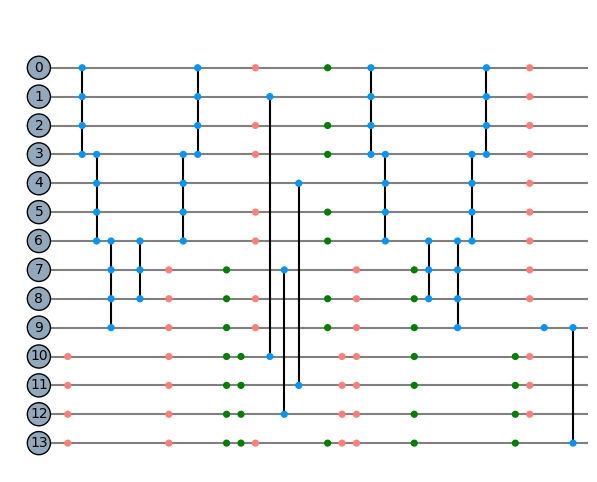

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

In [ ]:
from hierarqcal import (
    Qcycle,
    Qmotif,
    Qinit,
    Qmask,
    Qunmask,
    Qpivot,
    plot_circuit,
    plot_motif,
    get_tensor_as_f,
    Qunitary,
    Qhierarchy,
)
import numpy as np
import sympy as sp
import itertools as it# Define the carry motif function
def carry(r):
    if r == 1:
        return carry_motif
    else:
        return Qinit(4) + carry_motif + Qunmask("previous")

# Define the sum motif function
def sum(r=1):
    if r == 1:
        return Qinit(3) + Qpivot("*1", merge_within="01", mapping=cnot)
    else:
        return Qinit(3) + Qpivot("1*", merge_within="01", mapping=cnot)

# Define the carry sum motif function
def carry_sum(r=1):
    if r == 1:
        return Qinit(4) + Qpivot("1*", merge_within="1111", mapping=carry(-r)) + Qpivot("1*", merge_within="111", mapping=sum(r))
    else:
        return Qinit(4) + Qpivot("1*", merge_within="1111", mapping=carry(-r).reverse()) + Qpivot("1*", merge_within="111", mapping=sum(r))

# Define the cnot sum motif function
def cnot_sum(r):
    if r == 1:
        return Qinit(3) + Qpivot("*1", merge_within="11", mapping=cnot) + Qpivot("*1", merge_within="111", mapping=sum(r))
    else:
        return Qinit(3) + Qpivot("*1", merge_within="11", mapping=cnot) + Qpivot("*1", merge_within="111", mapping=sum(r)).reverse()

# Define the carry layer function
def carry_layer(r=1):
    return Qcycle(1, 3, 0, mapping=carry(r), boundary="open", edge_order=[r])

# Define the carry sum layer function
def carry_sum_layer(r=1):
    if r == 1:
        return Qmask("*111") + Qcycle(1, 3, 0, boundary="open", mapping=carry_sum(r), edge_order=[-r]) + Qunmask("previous")
    else:
        return Qmask("*111") + Qcycle(1, 3, 0, boundary="open", mapping=carry_sum(r).reverse(), edge_order=[-r]) + Qunmask("previous")

# Define the addition_mod_n function
addition_mod_n = (
    Qinit(nq)
    + addition
    + swap_an
    + subtraction
    + ctrl_not_bc_tmp_x
    + reset_if_overflow
    + addition
    + reset_if_overflow
    + swap_an
    + subtraction
    + ctrl_not_bc_tmp
    + addition
)

# Print the addition_mod_n circuit
print(addition_mod_n)

plot_circuit(addition_mod_n)


References




- "Elementary Number Theory" by David M. Burton - This book provides a comprehensive introduction to elementary number theory, including modular arithmetic.

- "An Introduction to the Theory of Numbers" by G.H. Hardy and E.M. Wright - This classic text covers various topics in number theory, including modular arithmetic, with clear explanations and examples.

- [hierarqcal Package](https://github.com/matt-lourens/hierarqcal)